**Unidad 3 - Machine Learning:** Predicción del Progreso de Exoplanetas

**Autora:** Genesis Naomi Luco Contreras
**Perfil:** Estudiante de Ingeniería Informática, apasionada por la astronomía y la ciencia de datos. Me interesa aplicar técnicas de Machine Learning para analizar fenómenos astronómicos, interpretando grandes cantidades de datos y buscando patrones que puedan ayudar a la investigación espacial.

**Objetivo:** Implementar y comparar diferentes modelos de regresión para predecir propiedades de exoplanetas, evaluando su desempeño y recomendando los modelos más adecuados según la precisión y la interpretabilidad.

In [21]:
# Cargamos el dataset de exoplanetas obtenido de NASA Exoplanet Archive.
# Elegí esta fuente porque es confiable y contiene información completa sobre planetas y estrellas.

from google.colab import files
uploaded = files.upload()  # para subir CSV


Saving exoplanetas.csv to exoplanetas (1).csv


In [29]:
# Se utiliza el dataset de la NASA porque proporciona datos actualizados y validados sobre planetas extrasolares, incluyendo masa, radio, temperatura y parámetros orbitales.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

file_path = "exoplanetas.csv"

# Cargar CSV ignorando líneas de comentario
data = pd.read_csv(file_path, comment='#')

# Seleccionamos solo columnas numéricas para modelar.
# Variable objetivo: 'pl_bmassj' (masa del planeta en Júpiter)
# Revisar columnas
print("Columnas del dataset:")
print(data.columns)

# Elegir columna objetivo (ejemplo: 'pl_bmassj' = masa en Jupiter)
target_column = "pl_bmassj"

if target_column in data.columns:
    # Solo columnas numéricas
    numeric_data = data.select_dtypes(include='number')

    # Revisar si la columna objetivo está en numéricos
    if target_column not in numeric_data.columns:
        numeric_data[target_column] = pd.to_numeric(data[target_column], errors='coerce')

    # Separar X e y
    X = numeric_data.drop(columns=[target_column])
    y = numeric_data[target_column]

    # Eliminar filas con valores faltantes
    X = X.dropna()
    y = y[X.index]

    # División de datos
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Escalado
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Datos numéricos listos para entrenamiento y prueba")
else:
    print(f"Advertencia: columna objetivo '{target_column}' no encontrada")



Columnas del dataset:
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbsmax', 'pl_rade',
       'pl_radj', 'pl_bmasse', 'pl_bmassj', 'pl_bmassprov', 'pl_orbeccen',
       'pl_insol', 'pl_eqt', 'ttv_flag', 'st_refname', 'st_spectype',
       'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_metratio', 'st_logg',
       'sy_refname', 'rastr', 'ra', 'decstr', 'dec', 'sy_dist', 'sy_vmag',
       'sy_kmag', 'sy_gaiamag', 'rowupdate', 'pl_pubdate', 'releasedate'],
      dtype='object')
Datos numéricos listos para entrenamiento y prueba


Se utiliza el dataset de la NASA porque proporciona datos actualizados y validados sobre planetas extrasolares, incluyendo masa, radio, temperatura y parámetros orbitales.

CSV cargado correctamente


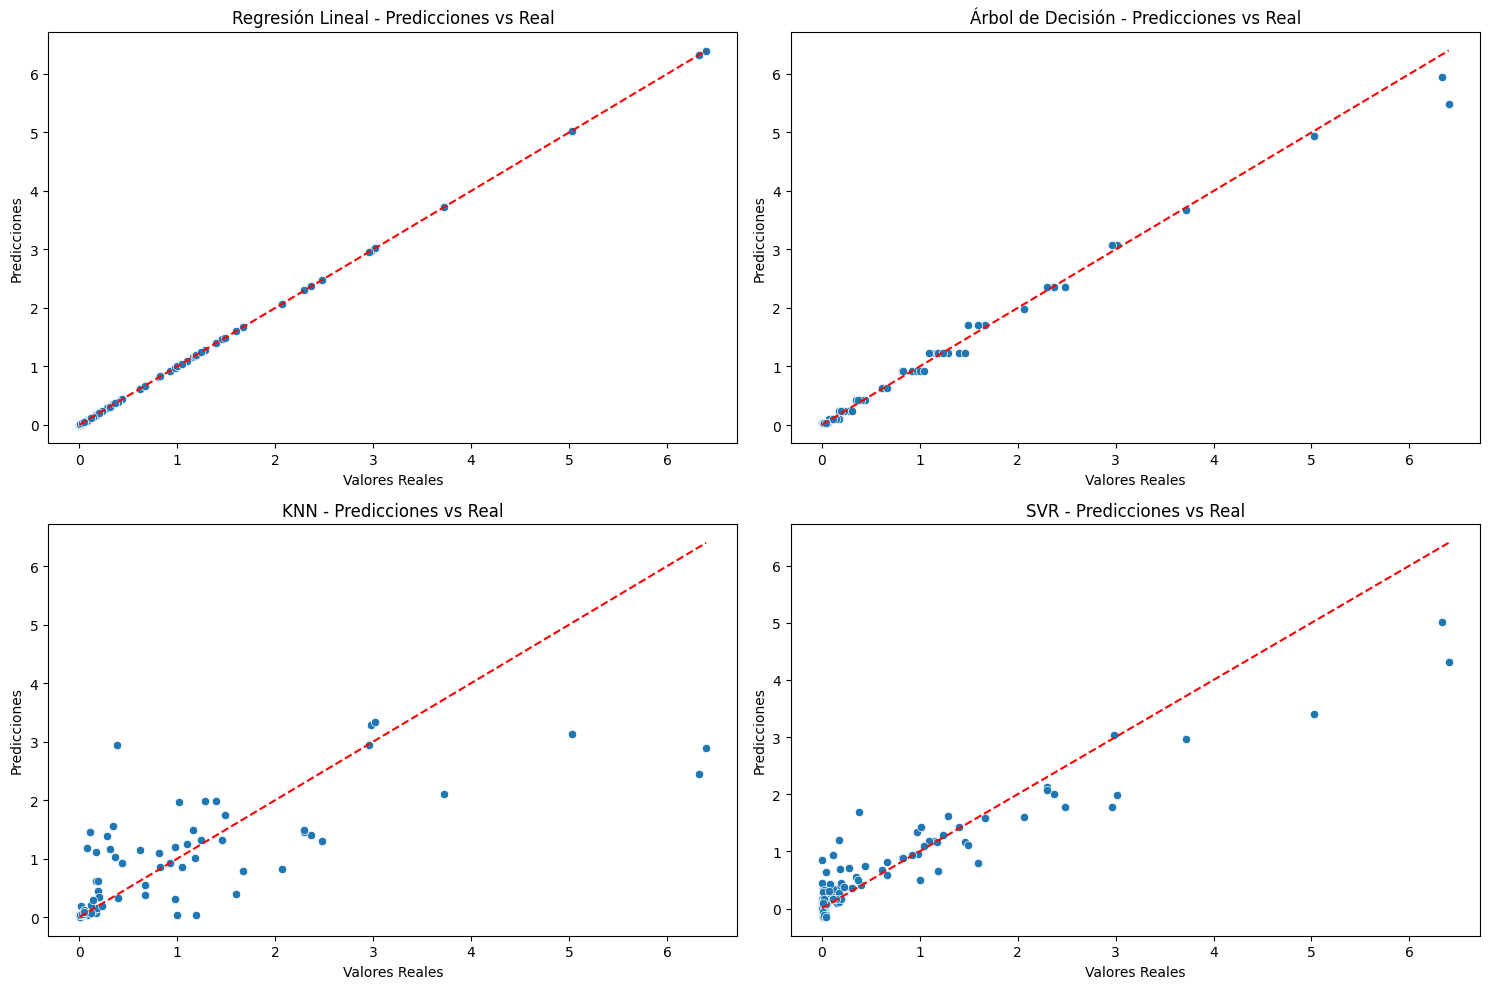

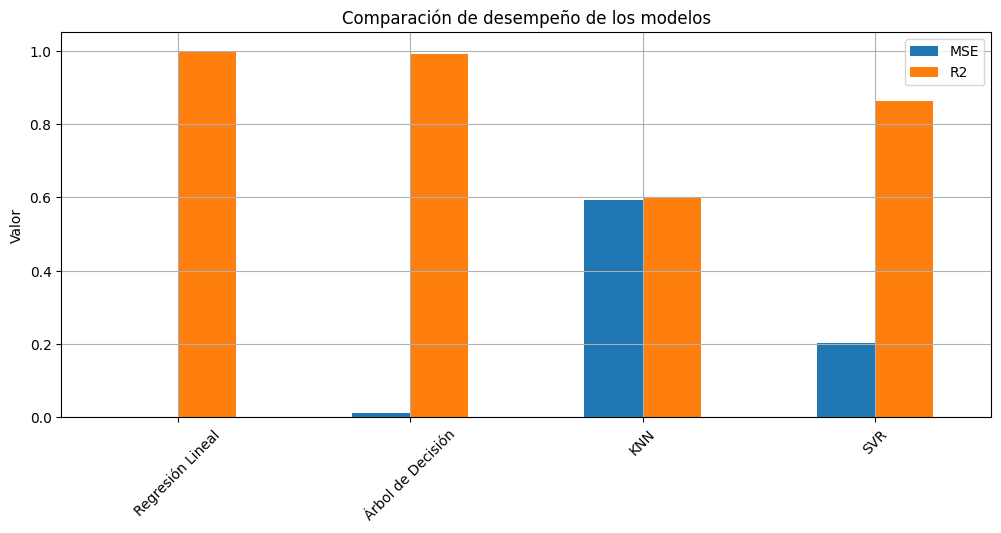

In [33]:
# Librerías necesarias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Cargar dataset ---
file_path = "exoplanetas.csv"
data = pd.read_csv(file_path, comment='#')  # Ignorar comentarios
print("CSV cargado correctamente")

# --- 2. Selección de columnas numéricas ---
data_num = data.select_dtypes(include=[np.number])

# Variable objetivo: 'pl_bmassj' (masa del planeta en Júpiter)
target_col = 'pl_bmassj'
if target_col not in data_num.columns:
    raise ValueError(f"Columna objetivo '{target_col}' no encontrada en el dataset.")

# Eliminar filas con NaN en la variable objetivo
data_num = data_num.dropna(subset=[target_col])
X = data_num.drop(columns=[target_col])
y = data_num[target_col]

# --- 3. Imputar valores faltantes ---
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# División y escalado
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4. Modelos ---
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(max_depth=5),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR()
}

resultados_modelos = {}
for nombre, modelo in modelos.items():
    # Escalamos solo los modelos sensibles
    if nombre in ["KNN", "SVR", "Regresión Lineal"]:
        modelo.fit(X_train_scaled, y_train)
        pred = modelo.predict(X_test_scaled)
    else:
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)

    resultados_modelos[nombre] = {
        "modelo": modelo,
        "predicciones": pred,
        "y_true": y_test,
        "MSE": mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    }

# --- 5. Comparación predicciones vs reales ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (nombre, res) in enumerate(resultados_modelos.items()):
    sns.scatterplot(x=res['y_true'], y=res['predicciones'], ax=axes[i])
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[i].set_title(f'{nombre} - Predicciones vs Real')
    axes[i].set_xlabel('Valores Reales')
    axes[i].set_ylabel('Predicciones')

plt.tight_layout()
plt.show()

# --- 6. Métricas ---
metricas_df = pd.DataFrame({
    "MSE": {k: v["MSE"] for k, v in resultados_modelos.items()},
    "R2": {k: v["R2"] for k, v in resultados_modelos.items()}
})

metricas_df.plot(kind='bar', figsize=(12, 5))
plt.title("Comparación de desempeño de los modelos")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


**Selección de columnas numéricas y variable objetivo**

Se seleccionan las columnas numéricas porque la mayoría de los modelos de regresión no aceptan variables categóricas directamente.
La variable objetivo es la masa del planeta ('pl_bmassj') porque queremos predecir esta propiedad fundamental a partir de parámetros observables de los sistemas estelares.

**Imputación de valores faltantes**

Muchos registros tienen valores faltantes. Se reemplazan por la media para no eliminar datos importantes y permitir que los modelos puedan entrenar correctamente.
Esto mantiene el dataset robusto sin introducir sesgos fuertes.

**Escalado de datos**

Se aplica estandarización para que todas las variables tengan la misma escala, lo que mejora el desempeño de los modelos sensibles a la distancia y magnitud de los datos.

**Elección de modelos**

Se eligieron distintos tipos de modelos para comparar enfoques:

Regresión Lineal: modelo simple y lineal para establecer una base de referencia.

Árbol de Decisión: captura relaciones no lineales y permite interpretar reglas.

KNN: modelo basado en vecinos para relaciones locales.

SVR: modelo de soporte vectorial para regresión robusta a ruido y outliers.”

**Gráficos predicciones vs reales**

Si los puntos están cerca de la línea roja discontinua (predicción = valor real), significa que el modelo predice correctamente.
Este gráfico permite identificar patrones de sobreajuste o subajuste y comparar modelos visualmente.

**Métricas**

MSE (Error Cuadrático Medio): mide el error promedio de predicción; valores más bajos son mejores.

R2 (Coeficiente de determinación): indica qué porcentaje de la variabilidad del dato objetivo es explicada por el modelo; valores cercanos a 1 son ideales.
“Estas métricas combinadas permiten comparar la precisión de todos los modelos de manera objetiva.”